## Swish Analytics Football Challenge - EDA

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
%matplotlib inline

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
pd.set_option('display.max_rows', None)

### Inputs

In [22]:
df = pd.read_csv("../outputs/merged_pbp_roster_2021_2023.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62126 entries, 0 to 62125
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   old_game_id                 62126 non-null  int64  
 1   play_id                     62126 non-null  int64  
 2   home_team                   62126 non-null  object 
 3   away_team                   62126 non-null  object 
 4   season                      62126 non-null  int64  
 5   season_type                 62126 non-null  object 
 6   week                        62126 non-null  int64  
 7   posteam                     62126 non-null  object 
 8   yardline_100                62126 non-null  float64
 9   half_seconds_remaining      62126 non-null  float64
 10  game_seconds_remaining      62126 non-null  float64
 11  game_half                   62126 non-null  object 
 12  down                        61841 non-null  float64
 13  ydstogo                     621

### EDA

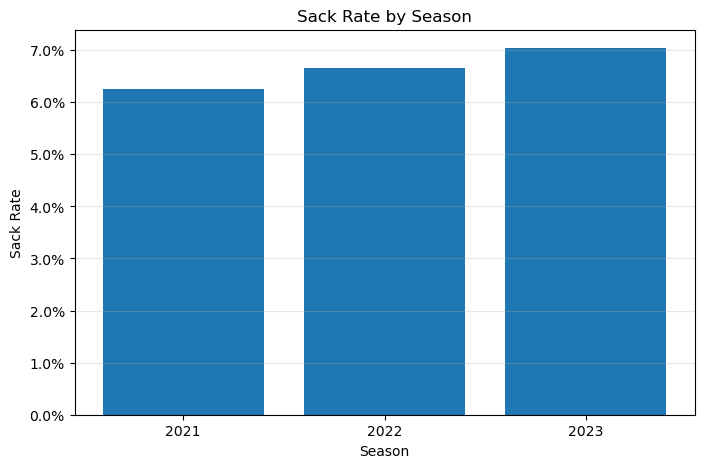

In [35]:
season_df = (
    df
    .groupby('season')
    .agg(
        dropbacks=('sack', 'size'),
        sacks=('sack', 'sum')
    )
    .reset_index()
)

season_df['sack_rate'] = season_df['sacks'] / season_df['dropbacks']

plt.figure(figsize=(8,5))
plt.bar(season_df['season'].astype(str), season_df['sack_rate'])

plt.title('Sack Rate by Season')
plt.ylabel('Sack Rate')
plt.xlabel('Season')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', alpha=0.3)

plt.show()

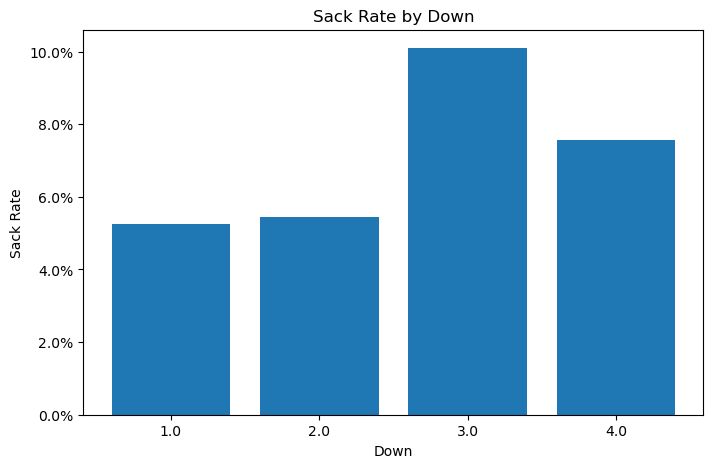

In [36]:
down_df = (
    df
    .groupby('down')
    .agg(
        dropbacks=('sack', 'size'),
        sacks=('sack', 'sum')
    )
    .reset_index()
)

down_df['sack_rate'] = down_df['sacks'] / down_df['dropbacks']

plt.figure(figsize=(8,5))
plt.bar(down_df['down'].astype(str), down_df['sack_rate'])
plt.title('Sack Rate by Down')
plt.ylabel('Sack Rate')
plt.xlabel('Down')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

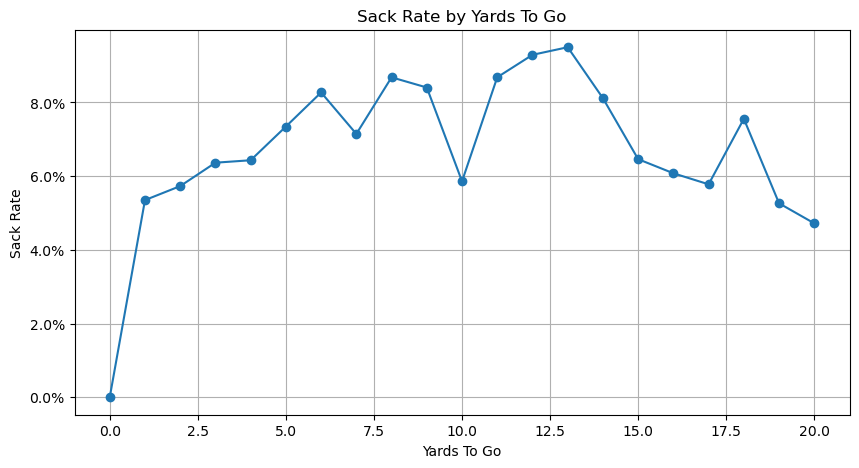

In [37]:
ydstogo_df = (
    df[df['ydstogo'] <= 20]
    .groupby('ydstogo')
    .agg(
        dropbacks=('sack', 'size'),
        sacks=('sack', 'sum')
    )
    .reset_index()
)

ydstogo_df['sack_rate'] = ydstogo_df['sacks'] / ydstogo_df['dropbacks']

plt.figure(figsize=(10,5))
plt.plot(ydstogo_df['ydstogo'], ydstogo_df['sack_rate'], marker='o')
plt.title('Sack Rate by Yards To Go')
plt.ylabel('Sack Rate')
plt.xlabel('Yards To Go')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True)
plt.show()

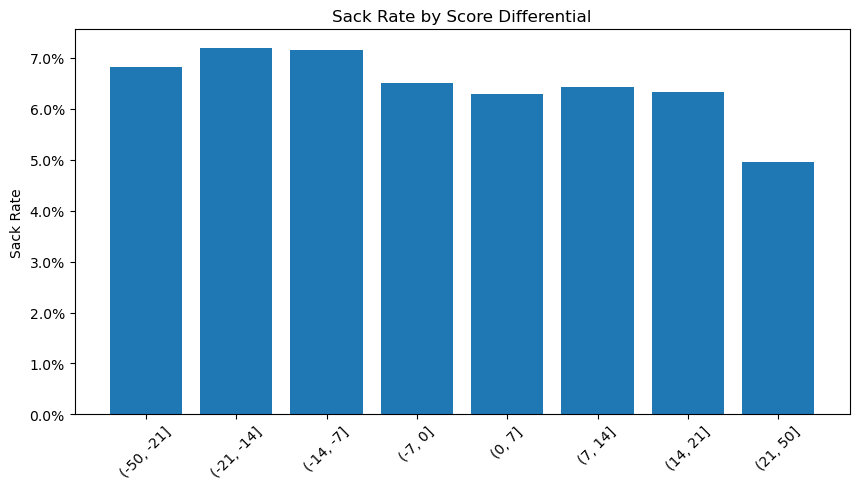

In [38]:
score_df = df.copy()

score_df['score_diff_bin'] = pd.cut(
    score_df['score_differential'],
    bins=[-50,-21,-14,-7,0,7,14,21,50]
)

score_df = (
    score_df
    .groupby('score_diff_bin')
    .agg(
        dropbacks=('sack', 'size'),
        sacks=('sack', 'sum')
    )
    .reset_index()
)

score_df['sack_rate'] = score_df['sacks'] / score_df['dropbacks']

plt.figure(figsize=(10,5))
plt.bar(score_df['score_diff_bin'].astype(str), score_df['sack_rate'])
plt.title('Sack Rate by Score Differential')
plt.ylabel('Sack Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.show()

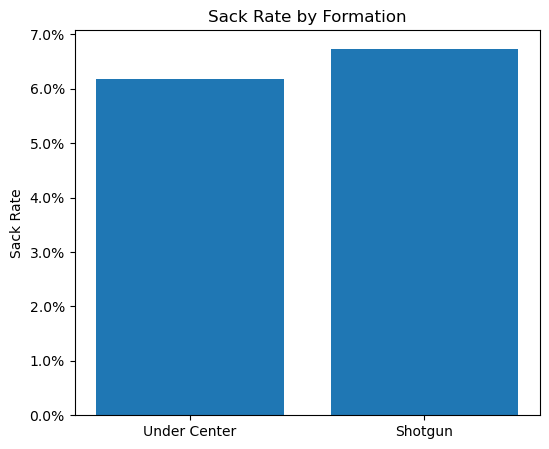

In [39]:
shotgun_df = (
    df
    .groupby('shotgun')
    .agg(
        dropbacks=('sack', 'size'),
        sacks=('sack', 'sum')
    )
    .reset_index()
)

shotgun_df['sack_rate'] = shotgun_df['sacks'] / shotgun_df['dropbacks']

plt.figure(figsize=(6,5))
plt.bar(
    shotgun_df['shotgun'].map({0:'Under Center',1:'Shotgun'}),
    shotgun_df['sack_rate']
)

plt.title('Sack Rate by Formation')
plt.ylabel('Sack Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

In [13]:
qb_df = (
    df
    .groupby('passer_player_name')
    .agg(
        dropbacks=('sack','size'),
        sacks=('sack','sum')
    )
    .reset_index()
)

qb_df = qb_df[qb_df['dropbacks'] >= 100]

qb_df['sack_rate'] = qb_df['sacks'] / qb_df['dropbacks']

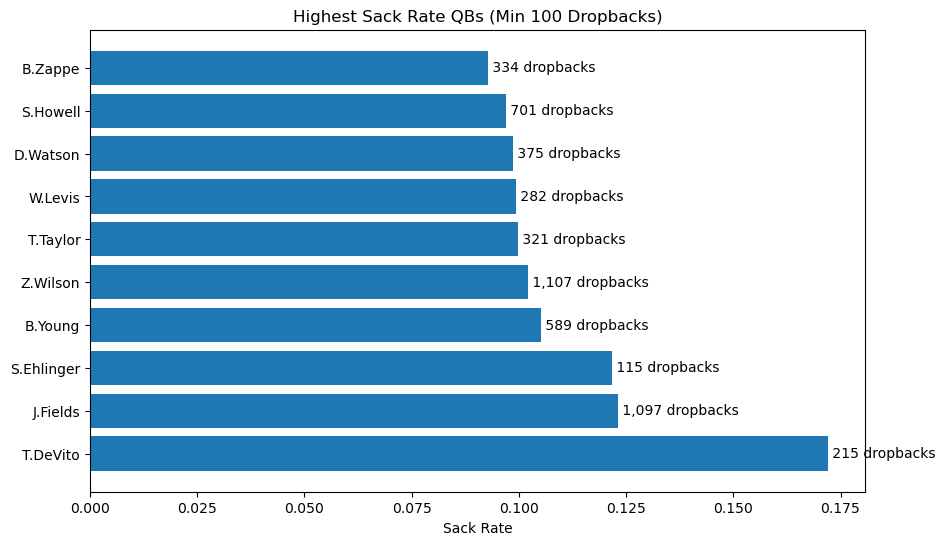

In [41]:
top10 = qb_df.nlargest(10, 'sack_rate')

plt.figure(figsize=(10,6))

bars = plt.barh(
    top10['passer_player_name'],
    top10['sack_rate']
)

for bar, db in zip(bars, top10['dropbacks']):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f' {db:,} dropbacks',
        va='center'
    )

plt.title('Highest Sack Rate QBs (Min 100 Dropbacks)')
plt.xlabel('Sack Rate')
plt.show()

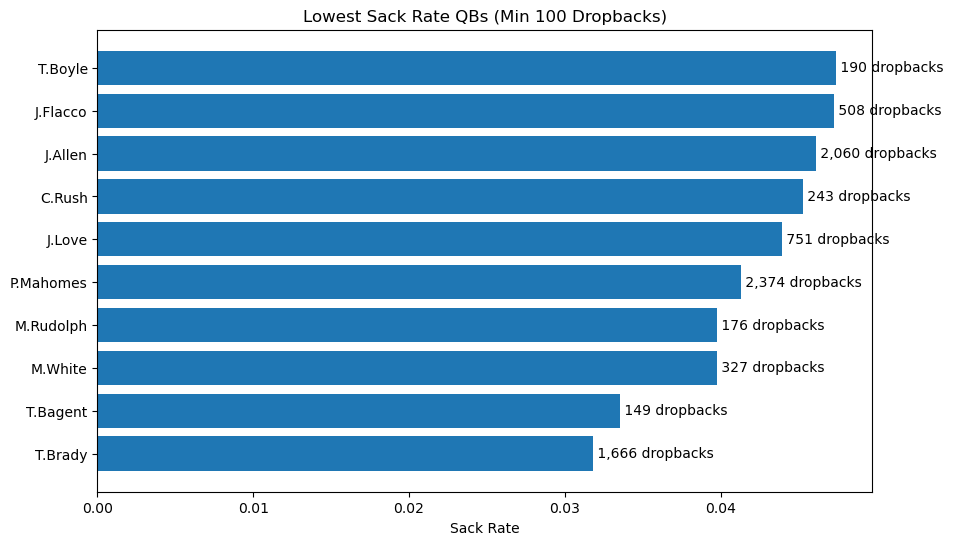

In [16]:
bottom10 = qb_df.nsmallest(10, 'sack_rate')

plt.figure(figsize=(10,6))

bars = plt.barh(
    bottom10['passer_player_name'],
    bottom10['sack_rate']
)

for bar, db in zip(bars, bottom10['dropbacks']):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f' {db:,} dropbacks',
        va='center'
    )

plt.title('Lowest Sack Rate QBs (Min 100 Dropbacks)')
plt.xlabel('Sack Rate')
plt.show()

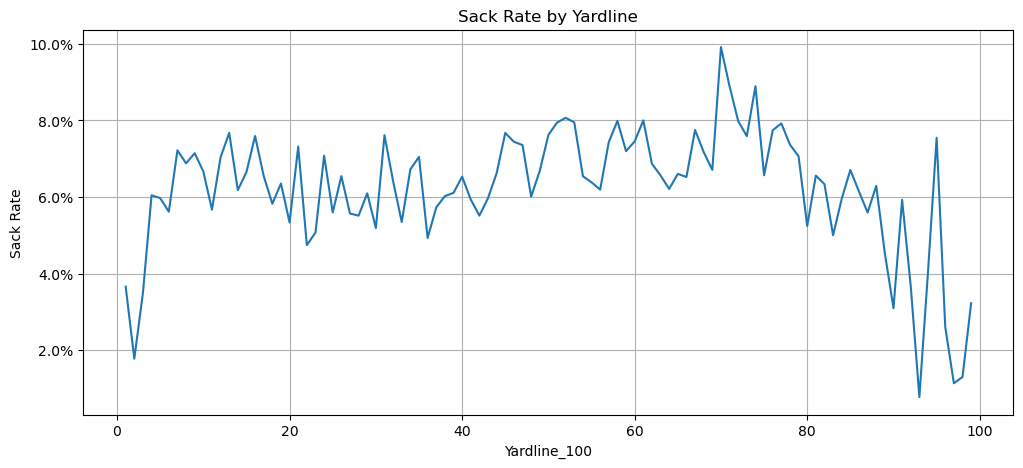

In [42]:
yardline_df = (
    df
    .groupby('yardline_100')
    .agg(
        dropbacks=('sack', 'size'),
        sacks=('sack', 'sum')
    )
    .reset_index()
)

yardline_df = yardline_df[yardline_df['dropbacks'] >= 50]

yardline_df['sack_rate'] = (
    yardline_df['sacks'] /
    yardline_df['dropbacks']
)

plt.figure(figsize=(12,5))
plt.plot(
    yardline_df['yardline_100'],
    yardline_df['sack_rate']
)

plt.title('Sack Rate by Yardline')
plt.xlabel('Yardline_100')
plt.ylabel('Sack Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True)
plt.show()

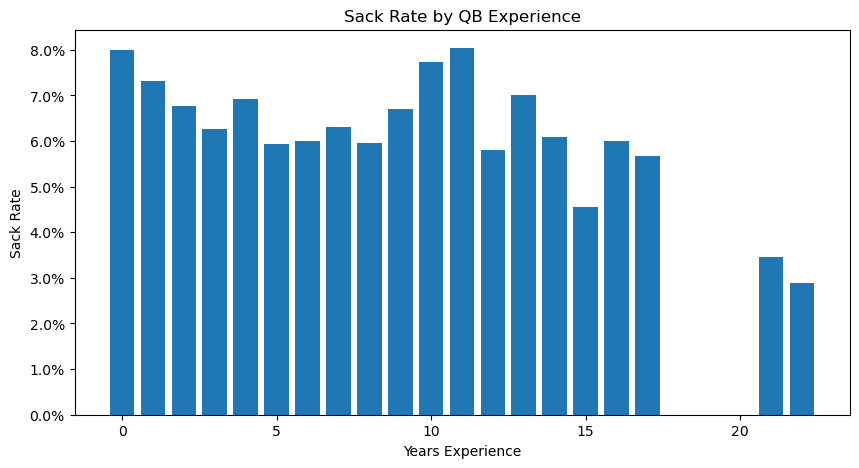

In [43]:
exp_df = (
    df
    .groupby('years_exp')
    .agg(
        dropbacks=('sack', 'size'),
        sacks=('sack', 'sum')
    )
    .reset_index()
)

exp_df = exp_df[exp_df['dropbacks'] >= 100]

exp_df['sack_rate'] = (
    exp_df['sacks'] /
    exp_df['dropbacks']
)

plt.figure(figsize=(10,5))
plt.bar(
    exp_df['years_exp'],
    exp_df['sack_rate']
)

plt.title('Sack Rate by QB Experience')
plt.xlabel('Years Experience')
plt.ylabel('Sack Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

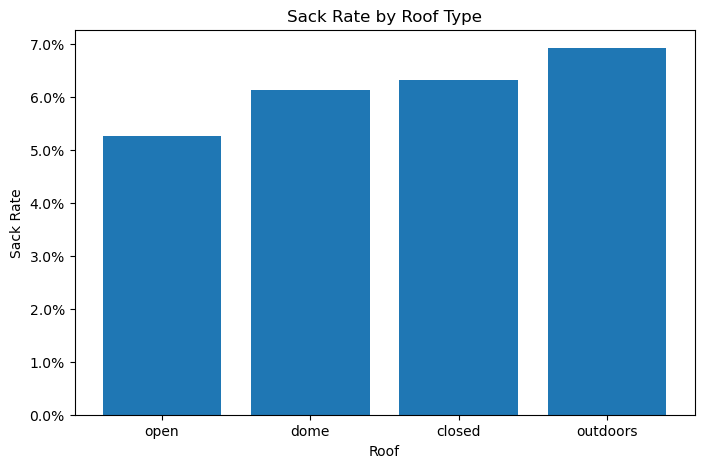

In [44]:
roof_df = (
    df
    .groupby('roof')
    .agg(
        dropbacks=('sack', 'size'),
        sacks=('sack', 'sum')
    )
    .reset_index()
)

roof_df['sack_rate'] = (
    roof_df['sacks'] /
    roof_df['dropbacks']
)

roof_df = roof_df.sort_values('sack_rate')

plt.figure(figsize=(8,5))
plt.bar(
    roof_df['roof'],
    roof_df['sack_rate']
)

plt.title('Sack Rate by Roof Type')
plt.xlabel('Roof')
plt.ylabel('Sack Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

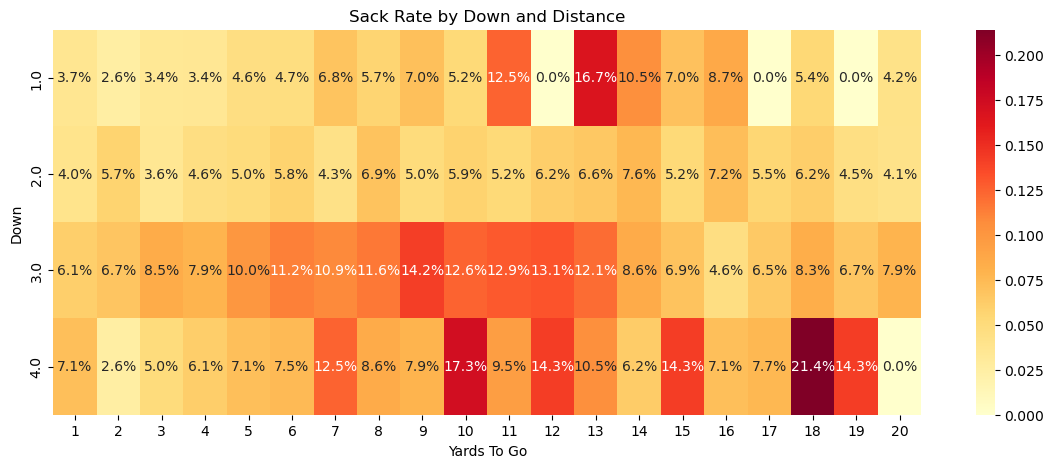

In [18]:
heatmap_df = (
    df[df['ydstogo'] <= 20]
    .groupby(['down', 'ydstogo'])
    .agg(
        sack_rate=('sack', 'mean')
    )
    .reset_index()
)

pivot_df = heatmap_df.pivot(
    index='down',
    columns='ydstogo',
    values='sack_rate'
)

plt.figure(figsize=(14,5))

sns.heatmap(
    pivot_df,
    annot=True,
    fmt='.1%',
    cmap='YlOrRd'
)

plt.title('Sack Rate by Down and Distance')
plt.xlabel('Yards To Go')
plt.ylabel('Down')
plt.show()

Lastly, this heatmap showing the relationship between down and distance shows that there are interaction effects at play. Sack rates are typically highest on third down but specifically when it is third and long. **When thinking of potential models, a logistic regression may not be the best fit because it does not automatically model interaction effects or nonlinear relationships. Since there are clearly interaction effects at play, a tree based model like XGBoost might be best. XGBoost may be more powerful than random forest as well because it utilizes boosting instead of bagging to build and learn on past trees.**

Logistic regression is still valuable as a baseline due to its interpretability and calibration properties.

### Feature Engineering EDA

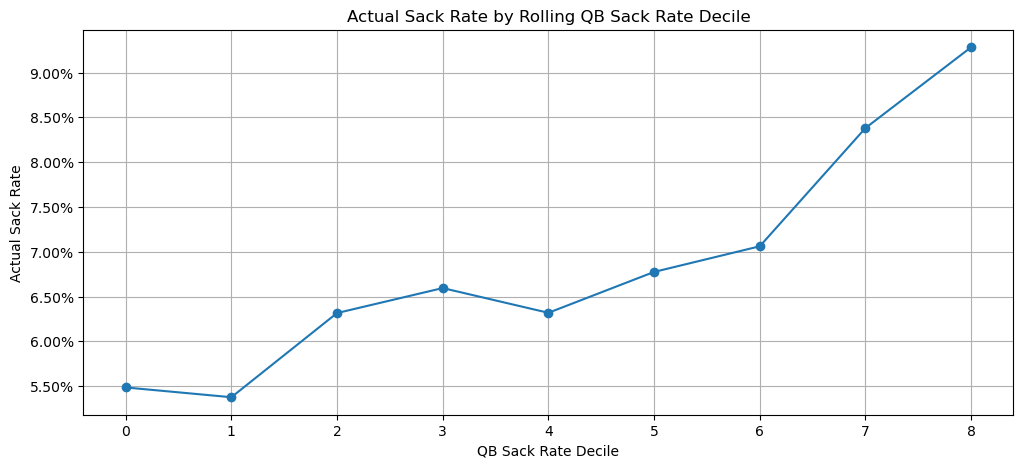

In [45]:
decile_df = df.copy()

decile_df['qb_decile'] = pd.qcut(
    decile_df['rolling_qb_sack_rate'],
    q=10,
    duplicates='drop'
)

qb_rate = (
    decile_df
    .groupby('qb_decile')
    .agg(
        sack_rate=('sack', 'mean'),
        dropbacks=('sack', 'size')
    )
    .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(
    range(len(qb_rate)),
    qb_rate['sack_rate'],
    marker='o'
)

plt.title('Actual Sack Rate by Rolling QB Sack Rate Decile')
plt.xlabel('QB Sack Rate Decile')
plt.ylabel('Actual Sack Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True)
plt.show()

For rolling_qb_sack_rate, the deciles sorts all plays from lowest to highest rolling QB sack rate and splits them into 10 equally-sized groups. Then for each decile we calculate the sack rate. As we can see, as the rolling sack rate increases, so does the actual sack rate which means this is a pretty good potential predictor.

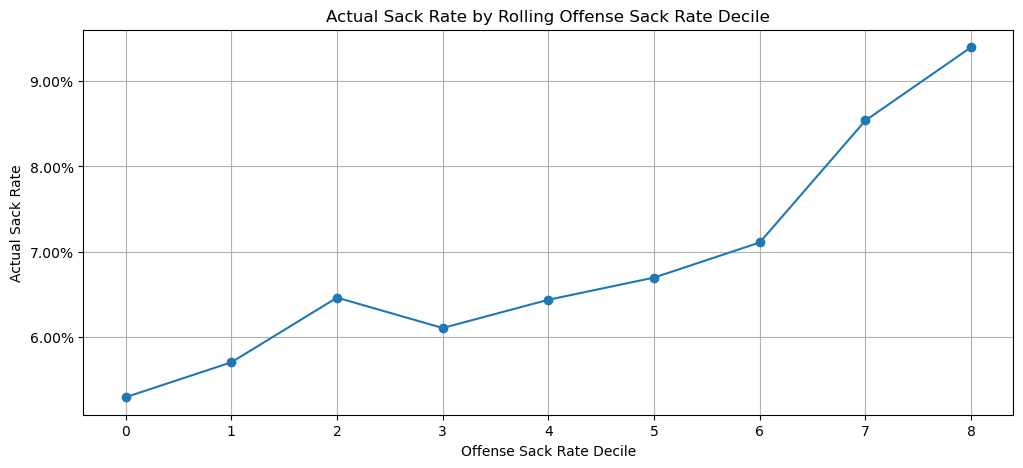

In [46]:
decile_df = df.copy()

decile_df['offense_decile'] = pd.qcut(
    decile_df['rolling_offense_sack_rate'],
    q=10,
    duplicates='drop'
)

off_rate = (
    decile_df
    .groupby('offense_decile')
    .agg(
        sack_rate=('sack', 'mean'),
        dropbacks=('sack', 'size')
    )
    .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(
    range(len(off_rate)),
    off_rate['sack_rate'],
    marker='o'
)

plt.title('Actual Sack Rate by Rolling Offense Sack Rate Decile')
plt.xlabel('Offense Sack Rate Decile')
plt.ylabel('Actual Sack Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True)
plt.show()

For rolling_offense_sack_rate, the deciles sorts all plays from lowest to highest rolling offense sack rate and splits them into 10 equally-sized groups. Then for each decile we calculate the sack rate. As we can see, as the rolling sack rate increases, so does the actual sack rate which means this is a pretty good potential predictor.

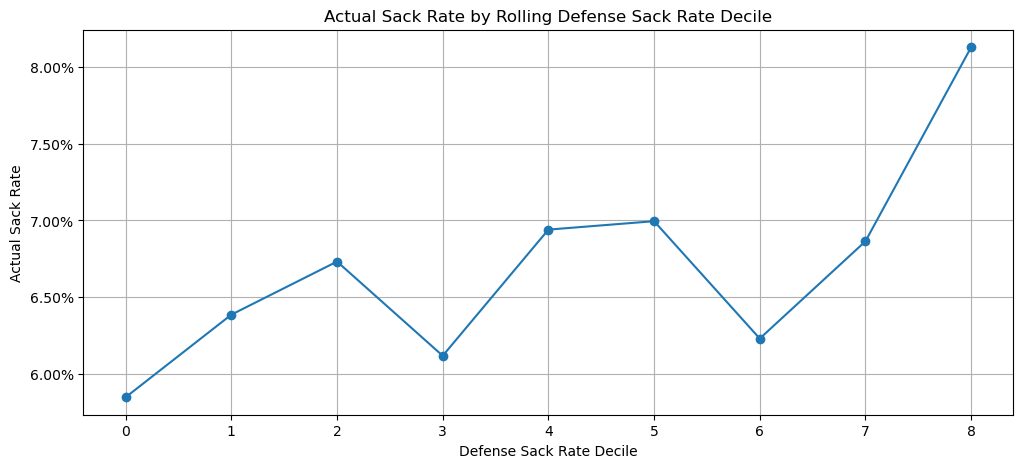

In [47]:
decile_df = df.copy()

decile_df['defense_decile'] = pd.qcut(
    decile_df['rolling_defense_sack_rate'],
    q=10,
    duplicates='drop'
)

def_rate = (
    decile_df
    .groupby('defense_decile')
    .agg(
        sack_rate=('sack', 'mean'),
        dropbacks=('sack', 'size')
    )
    .reset_index()
)

plt.figure(figsize=(12,5))
plt.plot(
    range(len(def_rate)),
    def_rate['sack_rate'],
    marker='o'
)

plt.title('Actual Sack Rate by Rolling Defense Sack Rate Decile')
plt.xlabel('Defense Sack Rate Decile')
plt.ylabel('Actual Sack Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True)
plt.show()

The rolling defense sack rate deciles do not seem to be as strong of a predictor.

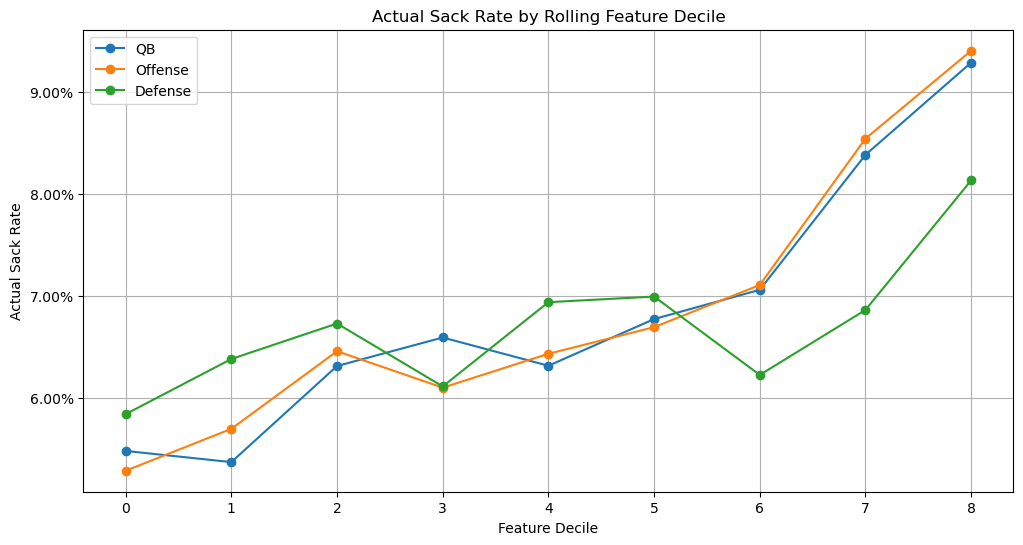

In [48]:
plt.figure(figsize=(12,6))

plt.plot(
    range(len(qb_rate)),
    qb_rate['sack_rate'],
    marker='o',
    label='QB'
)

plt.plot(
    range(len(off_rate)),
    off_rate['sack_rate'],
    marker='o',
    label='Offense'
)

plt.plot(
    range(len(def_rate)),
    def_rate['sack_rate'],
    marker='o',
    label='Defense'
)

plt.title('Actual Sack Rate by Rolling Feature Decile')
plt.xlabel('Feature Decile')
plt.ylabel('Actual Sack Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend()
plt.grid(True)

plt.show()